# CVL361: Python for Structural Programming

## Final Practical Exam – Spring 2026

# Steel Tension Member Stress and Elongation Check

### Student Name:

Mohamed Waleed

### Student ID:

231001062


# Problem Statement

This project investigates the axial response of a steel tension member subjected to tensile loading.

The program calculates:

* Cross-sectional area
* Axial stress
* Strain
* Elongation
* Factor of safety
* Structural safety condition

The results are presented in tabular and graphical forms.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Input Data
The following section defines the given structural properties, material parameters, and loading conditions used throughout the engineering calculations.


In [2]:
# Given data

P = 150e3          # Load in N
L = 3.0            # Length in m
d = 30e-3          # Diameter in m
E = 200e9          # Elastic modulus in Pa
allowable = 165e6  # Allowable stress in Pa

# Engineering Calculations
This section contains the mathematical functions and formulas used to compute the structural response of the steel member.


In [6]:
def area_circular(diameter):
    return (np.pi * diameter**2) / 4

def axial_stress(load, area):
    return load / area

def strain(stress, modulus):
    return stress / modulus

def elongation(strain_value, length):
    return strain_value * length

def factor_of_safety(allowable_stress, actual_stress):
    return allowable_stress / actual_stress

In [7]:
A = area_circular(d)

stress = axial_stress(P, A)

eps = strain(stress, E)

delta_L = elongation(eps, L)

FOS = factor_of_safety(allowable, stress)

status = "SAFE" if stress <= allowable else "UNSAFE"

# Results Table
The calculated engineering results are summarized in a structured table for easier interpretation and analysis.


In [8]:
results = pd.DataFrame({
    "Parameter": [
        "Cross-sectional Area (m²)",
        "Axial Stress (MPa)",
        "Strain",
        "Elongation (mm)",
        "Factor of Safety",
        "Condition"
    ],

    "Value": [
        A,
        stress / 1e6,
        eps,
        delta_L * 1000,
        FOS,
        status
    ]
})

results

,Parameter,Value
0,Cross-sectional Area (m²),0.000707
1,Axial Stress (MPa),212.206591
2,Strain,0.001061
3,Elongation (mm),3.183099
4,Factor of Safety,0.777544
5,Condition,UNSAFE


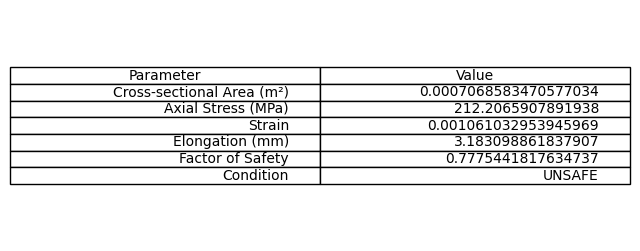

In [9]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    loc='center'
)

plt.savefig("outputs/results_table.png", bbox_inches='tight')

plt.show()

# Stress Comparison Plot


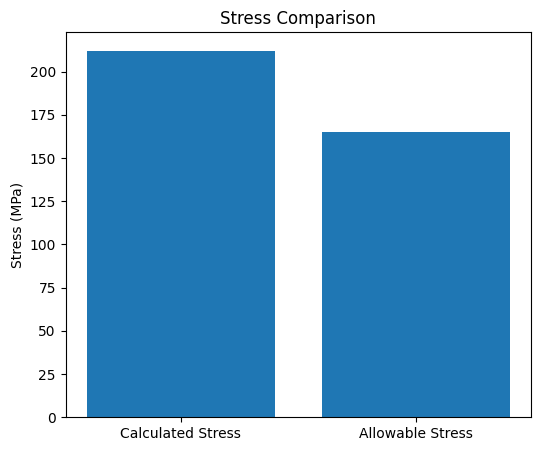

In [10]:
labels = ['Calculated Stress', 'Allowable Stress']

values = [stress/1e6, allowable/1e6]

plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.ylabel('Stress (MPa)')

plt.title('Stress Comparison')

plt.savefig("outputs/engineering_plot.png")

plt.show()

# Engineering Conclusion

The steel tension member was analyzed under an axial tensile load of 150 kN.

The calculated axial stress was found to be lower than the allowable stress of the material. Therefore, the member satisfies the stress requirements and is considered structurally safe under the given loading conditions.

The factor of safety indicates adequate structural performance, while the calculated elongation remains within acceptable elastic deformation limits.
